# Análise exploratória — somente desenvolvimento (80%)

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image

here = Path.cwd().resolve()
group = next(
    (p for p in [here, *here.parents] if (p / "config.py").exists() and (p / "lib").is_dir()),
    None,
)
if group is None:
    raise RuntimeError("Não encontrei analyses/grupo2. Abra o notebook dentro do projeto.")
if str(group) not in sys.path:
    sys.path.insert(0, str(group))

import config
from lib import data as data_lib, features, eda_stl
from lib import models_v2 as models
from lib.nb_boot import require_file, save_json, load_json
data_lib.ensure_output_dirs()
print("outputs →", config.OUTPUT_DIR)


outputs → C:\Users\brunacardoso-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Tech\Séries Temporais\trabalho_PLS_grupo2\pls-regration-comparation\analyses\grupo2\outputs


EDA limitada ao desenvolvimento; início do teste oculto: 2018-02-04 08:00:00


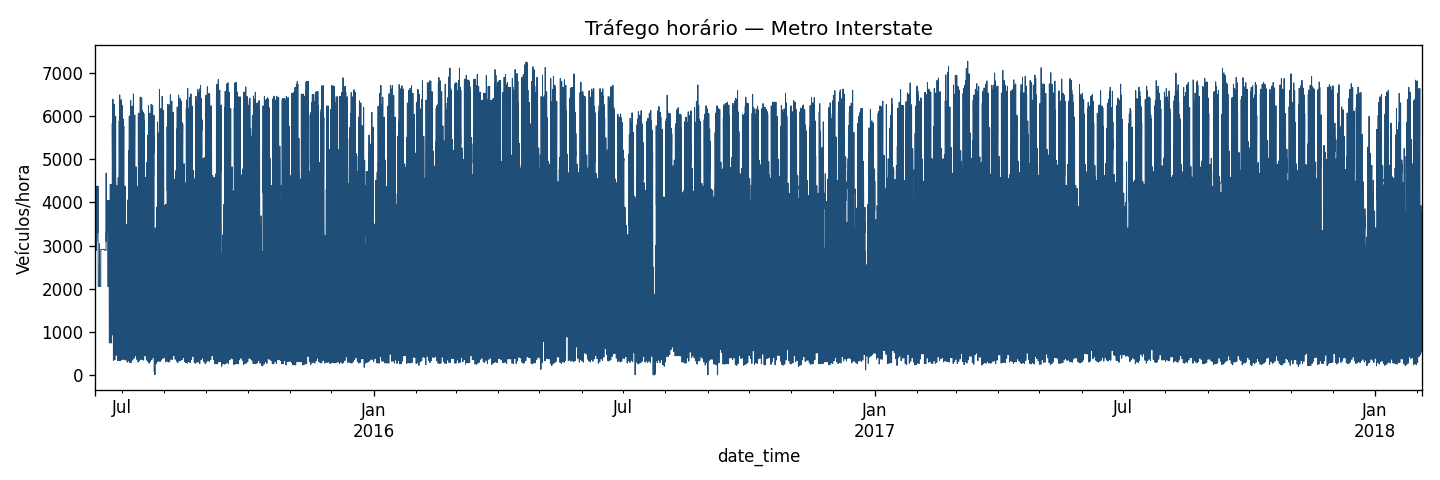

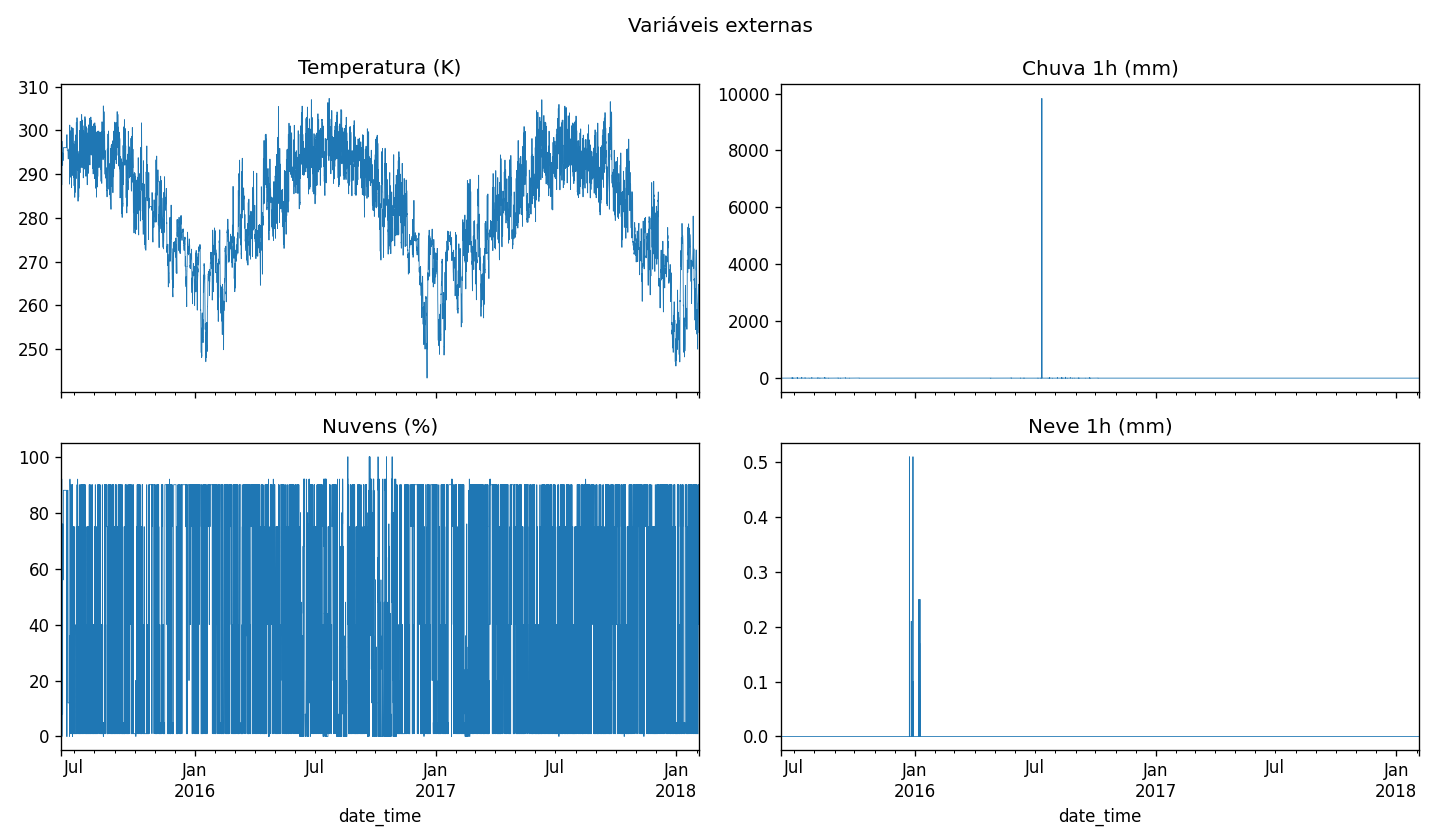

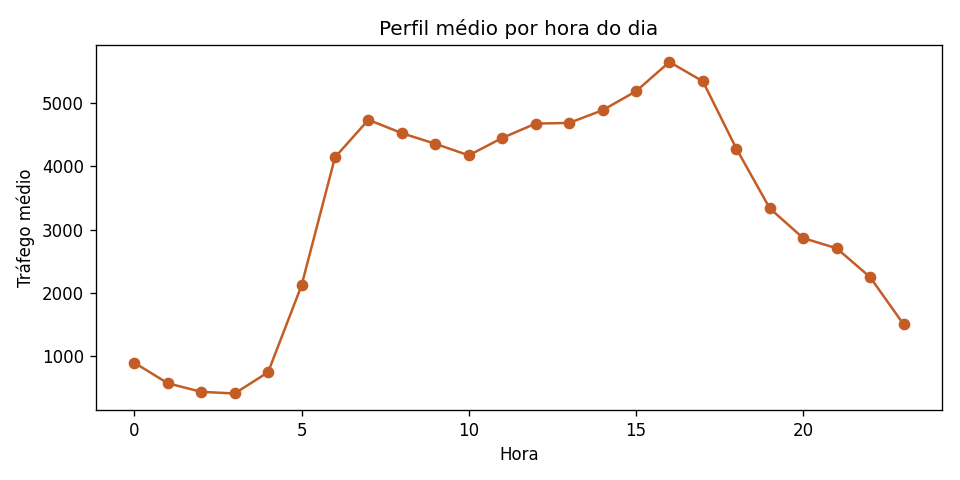

In [2]:
clean = pd.read_csv(
    require_file(config.DATA_DIR / "clean_hourly.csv", "02_limpeza_preparacao.ipynb"),
    parse_dates=[config.DATETIME_COL],
)
model_df = pd.read_csv(
    require_file(config.DATA_DIR / "modeling_frame.csv", "03_feature_engineering.ipynb"),
    parse_dates=[config.DATETIME_COL],
)
test_start = model_df.iloc[int(len(model_df) * config.TRAIN_RATIO)][config.DATETIME_COL]
development_clean = clean.loc[clean[config.DATETIME_COL] < test_start].copy()
summary = eda_stl.run_eda_and_stl(development_clean)
print("EDA limitada ao desenvolvimento; início do teste oculto:", test_start)
for name in ["01_serie_alvo.png", "02_externas.png", "03_perfil_horario.png"]:
    display(Image(filename=str(config.FIG_DIR / name)))
